# Data Prep: Clustering

In this notebook, the final feature matrix will be prepared for the models (both unsupervised clustering and supervised classification). This includes a short EDA, dropping / transforming of variables and, finally, saving the final dataset.

## 1) Load packages + Data

In [409]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from matplotlib.patches import Patch

In [410]:
url = ("https://gdi.berlin.de/services/wfs/lor_2021?service=WFS&version=2.0.0"
       "&request=GetFeature&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr = gpd.read_file(url)
plr["plr_id"] = plr["plr_id"].astype(str).str.zfill(8)

In [411]:
#load data 
df = pd.read_csv("../../data/final_datasets/feature_matrix_all_dimensions.csv", dtype={"plr_id": str})
df.sample(5)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_miete_unsicher,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_brw_trend_outlier,...,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_upscale_share_slope,com_tourism_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,com_has_gastro_structure
457,10300734,Biesdorf Süd,10 - Marzahn-Hellersdorf,17.65,1.272,0,0.964630,545.002413,0.112776,0,...,-0.000030,0.008366,-0.001952,0.000152,-0.043980,-0.000454,0.000776,0.003250,13.500000,1
321,07501135,Birnhornweg,07 - Tempelhof-Schöneberg,13.00,2.122,1,2.232558,669.994424,0.110290,0,...,0.002205,-0.012511,-0.001328,0.000062,-0.000303,0.000035,-0.001237,0.002515,7.500000,1
218,05200421,Spandauer Straße,05 - Spandau,10.91,0.550,1,1.354062,509.390106,-0.159507,0,...,-0.002033,0.021088,-0.001433,-0.002666,-0.093282,0.000000,0.000163,0.003548,3.000000,0
132,03601348,Senefelderstraße,03 - Pankow,18.09,0.984,0,1.316377,5000.023529,-0.182341,0,...,-0.000007,0.012131,0.000377,-0.000357,0.041349,0.000713,0.000528,0.002688,60.666667,1
36,01400937,Afrikanische Straße,01 - Mitte,16.86,1.442,0,2.377510,1035.770895,-0.360479,0,...,-0.000283,0.000242,-0.000417,-0.000663,0.001284,-0.001651,-0.000125,0.003152,34.666667,1


In [412]:
df.columns

Index(['plr_id', 'plr_name', 'bez', 're_miete_niveau', 're_miete_trend',
       're_miete_unsicher', 're_leerstandsquote', 're_brw_niveau',
       're_brw_trend', 're_brw_trend_outlier', 're_cov_wohnen_2025',
       're_dichte_all', 're_baualter_unsicher', 're_anteil_vor_1919',
       're_anteil_y1919_1948', 're_anteil_y1949_1978', 're_anteil_y1979_1990',
       're_anteil_y1991_2000', 're_anteil_y2001_2010', 're_anteil_y2011_plus',
       're_miet_dimension_anwendbar', 'soc_median_income_2023',
       'soc_young_to_middle_adult_share_2025',
       'soc_young_to_middle_adult_share_change_2021_2025',
       'soc_single_person_hh_share_2024',
       'soc_single_person_hh_share_change_2021_2024',
       'soc_households_without_minor_children_share_2024',
       'soc_households_without_minor_children_share_change_2021_2024',
       'soc_internal_migration_volume_rate_2025',
       'soc_internal_migration_volume_rate_change_2021_2025',
       'soc_internal_net_migration_rate_2025',
       '

In [413]:
df.shape

(542, 58)

## 2) Missing values

In [414]:
#look at missing values across columns
df.isna().sum().sort_values(ascending = False)

soc_median_income_2023                                          37
re_miete_trend                                                  16
re_miete_niveau                                                 11
soc_transfer_benefit_share_2024                                  7
soc_transfer_benefit_share_change_2020_2024                      7
com_upscale_share_level_2026                                     5
re_leerstandsquote                                               5
com_upscale_share_slope                                          4
soc_young_to_middle_adult_share_2025                             4
soc_single_parent_household_share_change_2021_2024               4
soc_young_to_middle_adult_share_change_2021_2025                 4
soc_single_parent_household_share_2024                           3
soc_households_without_minor_children_share_change_2021_2024     3
soc_internal_net_migration_rate_change_2021_2025                 2
soc_internal_net_migration_rate_2025                          

In [415]:
#Decision: drop soc_median_income_2023 as it is descriptive with many NaNs
df.drop(columns=["soc_median_income_2023"], inplace = True)

In [416]:
#Look at Missings per PLR - are values missing im many PLRs or are they concentrated on some PLRs? 
id_cols = ["plr_id", "plr_name", "bez"]
feature_cols = [c for c in df.columns if c not in id_cols]

df["n_missing"] = df[feature_cols].isna().sum(axis=1)

missing_plrs = (
    df.loc[df["n_missing"] > 0, id_cols + ["n_missing"]]
      .sort_values("n_missing", ascending=False)
      .reset_index(drop=True)
)

pd.set_option("display.max_rows", None)
print(missing_plrs.to_string(index=False))
print(f"\n{len(missing_plrs)} PLRs with missing values, out of {len(df)} total")

  plr_id                          plr_name                             bez  n_missing
03400831                      Pankower Tor                     03 - Pankow         27
06200418                           Landweg        06 - Steglitz-Zehlendorf         27
05300838                        Gartenfeld                    05 - Spandau         11
10100205 Gewerbegebiet Bitterfelder Straße        10 - Marzahn-Hellersdorf          8
04400725            Güterbahnhof Grunewald 04 - Charlottenburg-Wilmersdorf          7
03300515               Blankenburger Süden                     03 - Pankow          7
12200411               Schumacher-Quartier              12 - Reinickendorf          4
07200412                Schöneberger Linse       07 - Tempelhof-Schöneberg          3
08200729                    Britzer Garten                   08 - Neukölln          2
09300921                  Preußen Siedlung           09 - Treptow-Köpenick          2
03300413                         Karow Ost            

In [417]:
# for each PLR with gaps, list what columns are missing
for _, row in missing_plrs.iterrows():
    plr_row = df.loc[df["plr_id"] == row["plr_id"]].iloc[0]
    cols = [c for c in feature_cols if pd.isna(plr_row[c])]
    print(f'{row["plr_name"]} ({row["bez"]}) — {row["n_missing"]} missing:')
    print("   ", ", ".join(cols), "\n")

Pankower Tor (03 - Pankow) — 27 missing:
    re_miete_niveau, re_miete_trend, re_leerstandsquote, re_dichte_all, re_baualter_unsicher, re_anteil_vor_1919, re_anteil_y1919_1948, re_anteil_y1949_1978, re_anteil_y1979_1990, re_anteil_y1991_2000, re_anteil_y2001_2010, re_anteil_y2011_plus, soc_young_to_middle_adult_share_2025, soc_young_to_middle_adult_share_change_2021_2025, soc_single_person_hh_share_2024, soc_single_person_hh_share_change_2021_2024, soc_households_without_minor_children_share_2024, soc_households_without_minor_children_share_change_2021_2024, soc_internal_migration_volume_rate_2025, soc_internal_migration_volume_rate_change_2021_2025, soc_internal_net_migration_rate_2025, soc_internal_net_migration_rate_change_2021_2025, soc_transfer_benefit_share_2024, soc_transfer_benefit_share_change_2020_2024, soc_single_parent_household_share_2024, soc_single_parent_household_share_change_2021_2024, com_upscale_share_level_2026 

Landweg (06 - Steglitz-Zehlendorf) — 27 missing:
   

In [418]:
#inspect NA for gastro variables 
pid = "09300921"   # Preußen Siedlung 

key = df["plr_id"].astype(str).str.zfill(8)
row = df.loc[key == pid].T          # transpose: variables become rows
row.columns = ["value"]

with pd.option_context("display.max_rows", None):
    print(row.to_string())

                                                                              value
plr_id                                                                     09300921
plr_name                                                           Preußen Siedlung
bez                                                           09 - Treptow-Köpenick
re_miete_niveau                                                               12.08
re_miete_trend                                                                0.738
re_miete_unsicher                                                                 1
re_leerstandsquote                                                         2.453988
re_brw_niveau                                                            489.689649
re_brw_trend                                                               0.064568
re_brw_trend_outlier                                                              0
re_cov_wohnen_2025                                                         0

The PLR Preußen Siedlung has an n_gastro of 0, which means that the com_upscale_share_level_2026, com_upscale_share_slope should be 0 and not NA - this can be fixed immediately.

In [419]:
pid = "09300921"   # Preußen Siedlung
key = df["plr_id"].astype(str).str.zfill(8)
cols = ["com_upscale_share_level_2026", "com_upscale_share_slope"]

df.loc[key == pid, cols] = 0.0 #set share und slope to 0.0

# verify
print(df.loc[key == pid, ["plr_name"] + cols].to_string(index=False))

        plr_name  com_upscale_share_level_2026  com_upscale_share_slope
Preußen Siedlung                           0.0                      0.0


In [420]:
#remaining missing values
df.isna().sum().sort_values(ascending = False).head(10)

re_miete_trend                                        16
re_miete_niveau                                       11
soc_transfer_benefit_share_change_2020_2024            7
soc_transfer_benefit_share_2024                        7
re_leerstandsquote                                     5
soc_single_parent_household_share_change_2021_2024     4
soc_young_to_middle_adult_share_2025                   4
com_upscale_share_level_2026                           4
soc_young_to_middle_adult_share_change_2021_2025       4
com_upscale_share_slope                                3
dtype: int64

### Plot: NA per PLR

542 von 542 gematcht


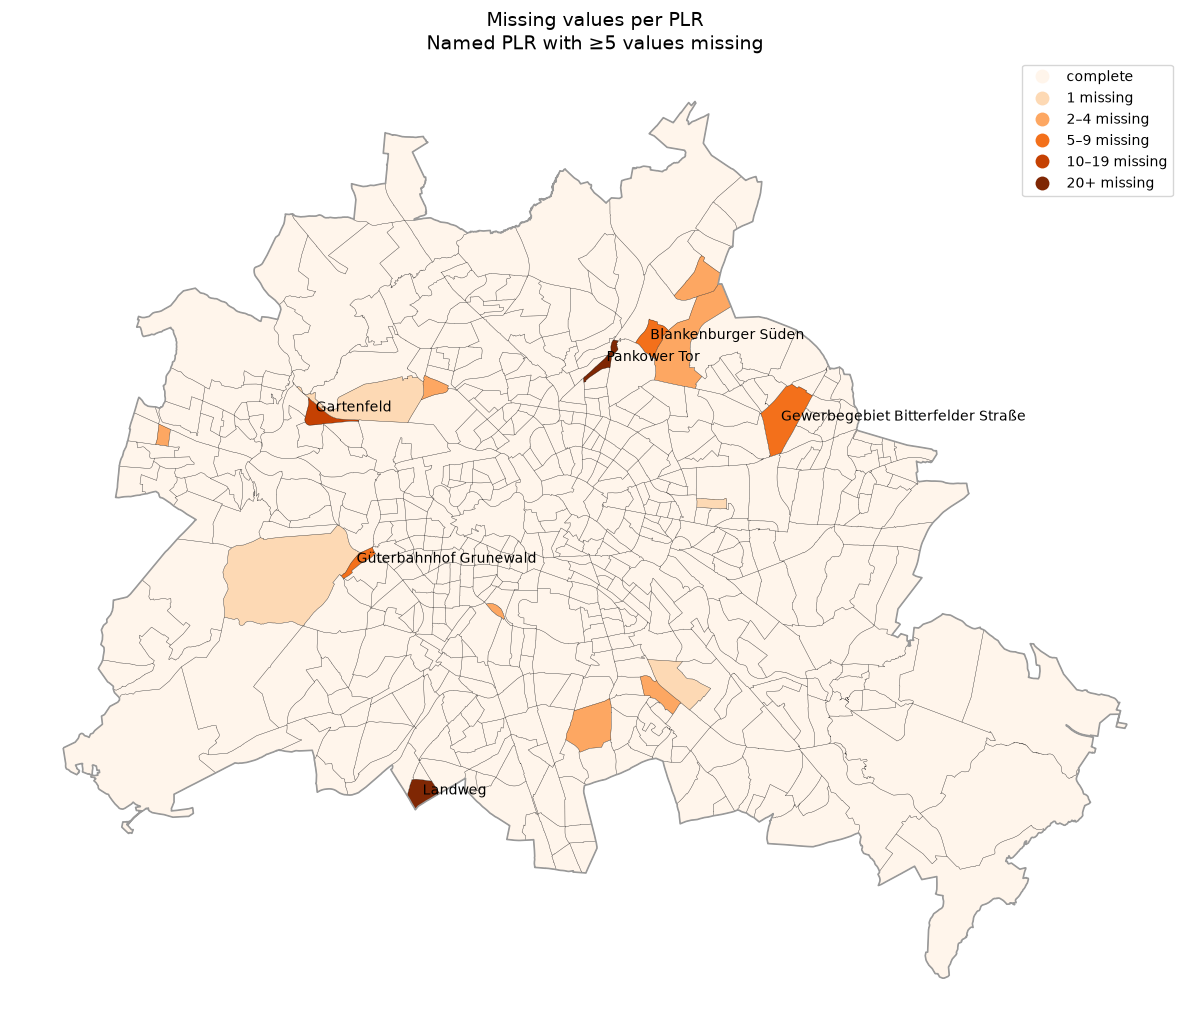

<Figure size 640x480 with 0 Axes>

In [421]:
#recompute n_missing + zero-padded join key
id_cols = ["plr_id", "plr_name", "bez"]
feature_cols = [c for c in df.columns if c not in id_cols]
df["n_missing"] = df[feature_cols].isna().sum(axis=1)

# join the counts onto the geometries
gdf = plr.merge(
    df.assign(plr_id=df["plr_id"].astype(str).str.zfill(8))[["plr_id", "n_missing"]],
    on="plr_id", how="left"
)

# sanity check — sollte ~542 sein
print(gdf["n_missing"].notna().sum(), "von", len(gdf), "gematcht")

berlin_outline = plr.dissolve()

# bin categories 
bins   = [-1, 0, 1, 4, 9, 19, np.inf]
labels = ["complete", "1 missing", "2–4 missing",
          "5–9 missing", "10–19 missing", "20+ missing"]
gdf["missing_cat"] = pd.cut(
    gdf["n_missing"].fillna(0),
    bins=bins,
    labels=labels
)

# 
fig, ax = plt.subplots(figsize=(12, 12))

# plot on map 
gdf.plot(
    column="missing_cat",
    categorical=True,
    legend=True,
    cmap="Oranges",
    edgecolor="none",
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "no geometry match"}
)

# alle plr boundary
gdf.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.25,
    alpha=0.5
)

# berlin boundary
berlin_outline.boundary.plot(
    ax=ax,
    edgecolor="#999999",
    linewidth=1.2
)

ax.set_title(
    "Missing values per PLR\nNamed PLR with ≥5 values missing",
    fontsize=14
)
ax.axis("off")

# worst offenders
for _, r in gdf[gdf["n_missing"] >= 5].iterrows():
    c = r.geometry.representative_point()
    ax.annotate(
        r["plr_name"],
        (c.x, c.y),
        fontsize=10,
        ha="left"
    )

plt.tight_layout()
plt.show()

plt.savefig("../../plots/EDA/NaNs_per_PLR.png", dpi=300, bbox_inches="tight")

#Result of inspecting the NaNs

Missing values are highly concentrated, not dispersed: 499 of 542 PLR are complete. The most affected — Landweg and Pankower Tor (27 each), plus Gartenfeld, Gewerbegebiet Bitterfelder Straße, Blankenburger Süden, Güterbahnhof Grunewald, and Schumacher-Quartier — are development sites, former railway/industrial land, and barely-populated quarters that legitimately lack structure across all three dimensions and are therefore dropped from the dataset. 



In [422]:
#drop PLRs that are non-residential (more )
non_residential = {
    "06200418": "Landweg",
    "03400831": "Pankower Tor",
    "05300838": "Gartenfeld",
    "10100205": "Gewerbegebiet Bitterfelder Straße",
    "03300515": "Blankenburger Süden",
    "04400725": "Güterbahnhof Grunewald",
    "12200411": "Schumacher-Quartier",
}
                      
df_model = df[~df["plr_id"].isin(non_residential)].copy()   
print(f"Dropped {len(non_residential)} non-residential PLR → {len(df_model)} remain")  

Dropped 7 non-residential PLR → 535 remain


In [423]:
#sanity check
print(f"Rows in newly created df_model: {len(df_model)}")
dropped = set(df["plr_id"]) - set(df_model["plr_id"])
print("Dropped PLR:")
print(df[df["plr_id"].isin(dropped)][["plr_id", "plr_name"]].to_string(index=False))

Rows in newly created df_model: 535
Dropped PLR:
  plr_id                          plr_name
03300515               Blankenburger Süden
03400831                      Pankower Tor
04400725            Güterbahnhof Grunewald
05300838                        Gartenfeld
06200418                           Landweg
10100205 Gewerbegebiet Bitterfelder Straße
12200411               Schumacher-Quartier


Now let's inspect the missings without those PLRs.

In [424]:
#inspect remaining missingness
n = len(df_model)
miss = df_model.isna().sum()
overview = pd.DataFrame({
    "n_missing": miss,
    "pct": (miss / n * 100).round(1),
})
overview = overview[overview["n_missing"] > 0].sort_values("n_missing", ascending=False)
print(overview)

                    n_missing  pct
re_miete_trend              9  1.7
re_miete_niveau             5  0.9
re_brw_niveau               1  0.2
re_brw_trend                1  0.2
re_cov_wohnen_2025          1  0.2


In [425]:
rent_cols = ["re_miete_niveau", "re_miete_trend"]
brw_cols  = ["re_brw_niveau", "re_brw_trend", "re_cov_wohnen_2025"]
all_gap   = rent_cols + brw_cols

#which block is missing for each affected PLR
affected = df_model[df_model[all_gap].isna().any(axis=1)].copy()

def missing_block(row):
    rent_missing = row[rent_cols].isna().any()
    brw_missing  = row[brw_cols].isna().any()
    if rent_missing and brw_missing: return "rent+brw"
    if rent_missing:                 return "rent only"
    if brw_missing:                  return "brw only"
    return "-"

affected["missing_block"] = affected.apply(missing_block, axis=1)

print(affected[["plr_id", "plr_name",
                "re_miete_niveau", "re_miete_trend",
                "re_brw_niveau", "re_cov_wohnen_2025",
                "re_miete_unsicher", "missing_block"]].to_string(index=False))

  plr_id           plr_name  re_miete_niveau  re_miete_trend  re_brw_niveau  re_cov_wohnen_2025  re_miete_unsicher missing_block
03300413          Karow Ost              NaN             NaN     500.022367            0.959013                  1     rent only
03300517        Märchenland              NaN             NaN     285.571015            0.115828                  1     rent only
04200207           Eichkamp            16.67             NaN     996.036121            0.034252                  1     rent only
05200419       Am Heideberg              NaN             NaN     469.435055            0.928344                  1     rent only
07200412 Schöneberger Linse            22.60           0.854            NaN                 NaN                  0      brw only
08200728         Ortolanweg              NaN             NaN     600.000000            0.084402                  1     rent only
08200729     Britzer Garten              NaN             NaN     625.333179            0.109536  

Rent data is missing in 9 PLRs, BRW data is missing in one PLR (Schöneberger Linse): 

Domain knowledge: Schöneberger Linse wasn't a residential area in 2022 and therefore doesn't have a BRW value. However, now it is a gentrifying kiez that should be taken into account. 

In [426]:
#two hypotheses why the rent data is missing: Neubaugebiete or non-residential? 

#bring fallzahl_mittel in from the angebotsmieten source (not in the merged matrix) ---
src = pd.read_csv("../../data/real_estate/final_variables/var1_2_angebotsmieten.csv", dtype={"plr_id": str})  # adjust path
src["plr_id"] = src["plr_id"].str.zfill(8)
df_check = df_model.merge(src[["plr_id", "fallzahl_mittel"]], on="plr_id", how="left")

#neubau share (or reuse re_neubau_share if already derived)
df_check["neubau_share"] = df_check["re_anteil_y2001_2010"] + df_check["re_anteil_y2011_plus"]

#therefore: two missingness groups
group_a = ["03300413", "03300517", "05200419", "08200728", "08200729"]  # fallzahl NaN: no offers -> niveau+trend missing
group_b = ["04200207", "09100306", "11300723", "12200414"]              # fallzahl 3-4: niveau present, trend missing

cols = ["plr_id", "plr_name", "fallzahl_mittel",
        "re_cov_wohnen_2025", "neubau_share", "re_anteil_vor_1919"]

print("GROUP A — no rental offers (fallzahl NaN):")
print(df_check[df_check["plr_id"].isin(group_a)][cols].round(3).to_string(index=False))
print("\nGROUP B — too few offers for a trend (fallzahl 3–4):")
print(df_check[df_check["plr_id"].isin(group_b)][cols].round(3).to_string(index=False))

GROUP A — no rental offers (fallzahl NaN):
  plr_id       plr_name  fallzahl_mittel  re_cov_wohnen_2025  neubau_share  re_anteil_vor_1919
03300413      Karow Ost              NaN               0.959         0.270               0.022
03300517    Märchenland              NaN               0.116         0.031               0.006
05200419   Am Heideberg              NaN               0.928         0.000               0.754
08200728     Ortolanweg              NaN               0.084         0.000               0.009
08200729 Britzer Garten              NaN               0.110         0.179               0.017

GROUP B — too few offers for a trend (fallzahl 3–4):
  plr_id      plr_name  fallzahl_mittel  re_cov_wohnen_2025  neubau_share  re_anteil_vor_1919
04200207      Eichkamp              3.0               0.034         0.021               0.023
09100306   Späthsfelde              3.0               0.242         0.141               0.027
11300723 Bornitzstraße              3.0            

None of the hypotheses are true:

Karow Ost (cov 0.96), Eichkamp (cov 0.03, fallzahl 3) and Am Heideberg (cov 0.93, 75% Altbau) are strongly residential but owner-occupied areas that don't generate rental listings. Märchenland/Ortolanweg/Britzer Garten are low-coverage green-edge areas or small peripheral settlement with minimal rental (Späthsfelde, cov 0.24, fallzahl 3). 

These will therefore be excluded from the dataset for modelling. Only Bornitzstraße is newly-built. All the rest is neither newly-built nor non-residential. 

Small caveat: building age is based on the Zensus 2022 Gebäude- und Wohnungszählung (Stichtag 15 May 2022) and therefore reflects the building stock as of that date. Construction completed after May 2022 is not captured, so PLR with major post-2022 development (e.g. the Schumacher-Quartier redevelopment) will under-represent their actual Neubau share. 

Schöneberger Linse with the BRW missing is - as stated already - a separate case. So is Bornitzstraße. 

In [427]:
#PLR with no tenant structure (owner-occupied) or predominantly garden/green —
no_tenant_structure = {
    "03300413": "Karow Ost",        #residential but zero rental offers — owner-occupied
    "05200419": "Am Heideberg",     #residential, no rental market — owner-occupied
    "03300517": "Märchenland",      #low coverage, no offers — garden/Siedlung
    "08200728": "Ortolanweg",       #low coverage, no offers — half garden
    "08200729": "Britzer Garten",   #park-adjacent, no offers — garden
    "04200207": "Eichkamp",         #villa colony, minimal rental — owner-occupied
    "09100306": "Späthsfelde",      #small peripheral settlement, minimal rental
    "12200414": "Tegel",            #2022 still the airport, 2026 no residential area yet built
    
}

df_model = df_model[~df_model["plr_id"].isin(no_tenant_structure)].copy()
print(f"Dropped {len(no_tenant_structure)} non-tenant PLR → {len(df_model)} remain")

Dropped 8 non-tenant PLR → 527 remain


### 3) Recoding Baualter Variable (sums up to 1 currently)

In [428]:
#derive two Baualter features, one with old buildings (altbau_share, Gründerzeit)
df_model["re_altbau_share"] = df_model["re_anteil_vor_1919"] 
#and one with newer buildings (from 2001 onwards)                      
df_model["re_neubau_share"] = (
    df_model["re_anteil_y2001_2010"] + df_model["re_anteil_y2011_plus"]            # 2001+
)

#energetic-modernisation potential is the complement of Neubau 
#However: NOT stored as a feature (near-constant + overlaps Altbau): 1 - re_neubau_share

#drop the 7 original bands (collapsed into the two shares above)
baualter_bands = [
    "re_anteil_vor_1919", "re_anteil_y1919_1948", "re_anteil_y1949_1978",
    "re_anteil_y1979_1990", "re_anteil_y1991_2000",
    "re_anteil_y2001_2010", "re_anteil_y2011_plus",
]
df_model = df_model.drop(columns=baualter_bands)

#verify the two new shares aren't redundant with each other or the market
checks = ["re_altbau_share", "re_neubau_share", "re_miete_niveau", "re_brw_niveau"]
print(df_model[checks].corr(method="spearman").round(2).to_string())
print(f"\nColumns now: {df_model.shape[1]}")

                 re_altbau_share  re_neubau_share  re_miete_niveau  re_brw_niveau
re_altbau_share             1.00            -0.04             0.61           0.73
re_neubau_share            -0.04             1.00             0.30          -0.11
re_miete_niveau             0.61             0.30             1.00           0.62
re_brw_niveau               0.73            -0.11             0.62           1.00

Columns now: 53


## 3) Exploration: Flag Variables

527 von 542 gematcht


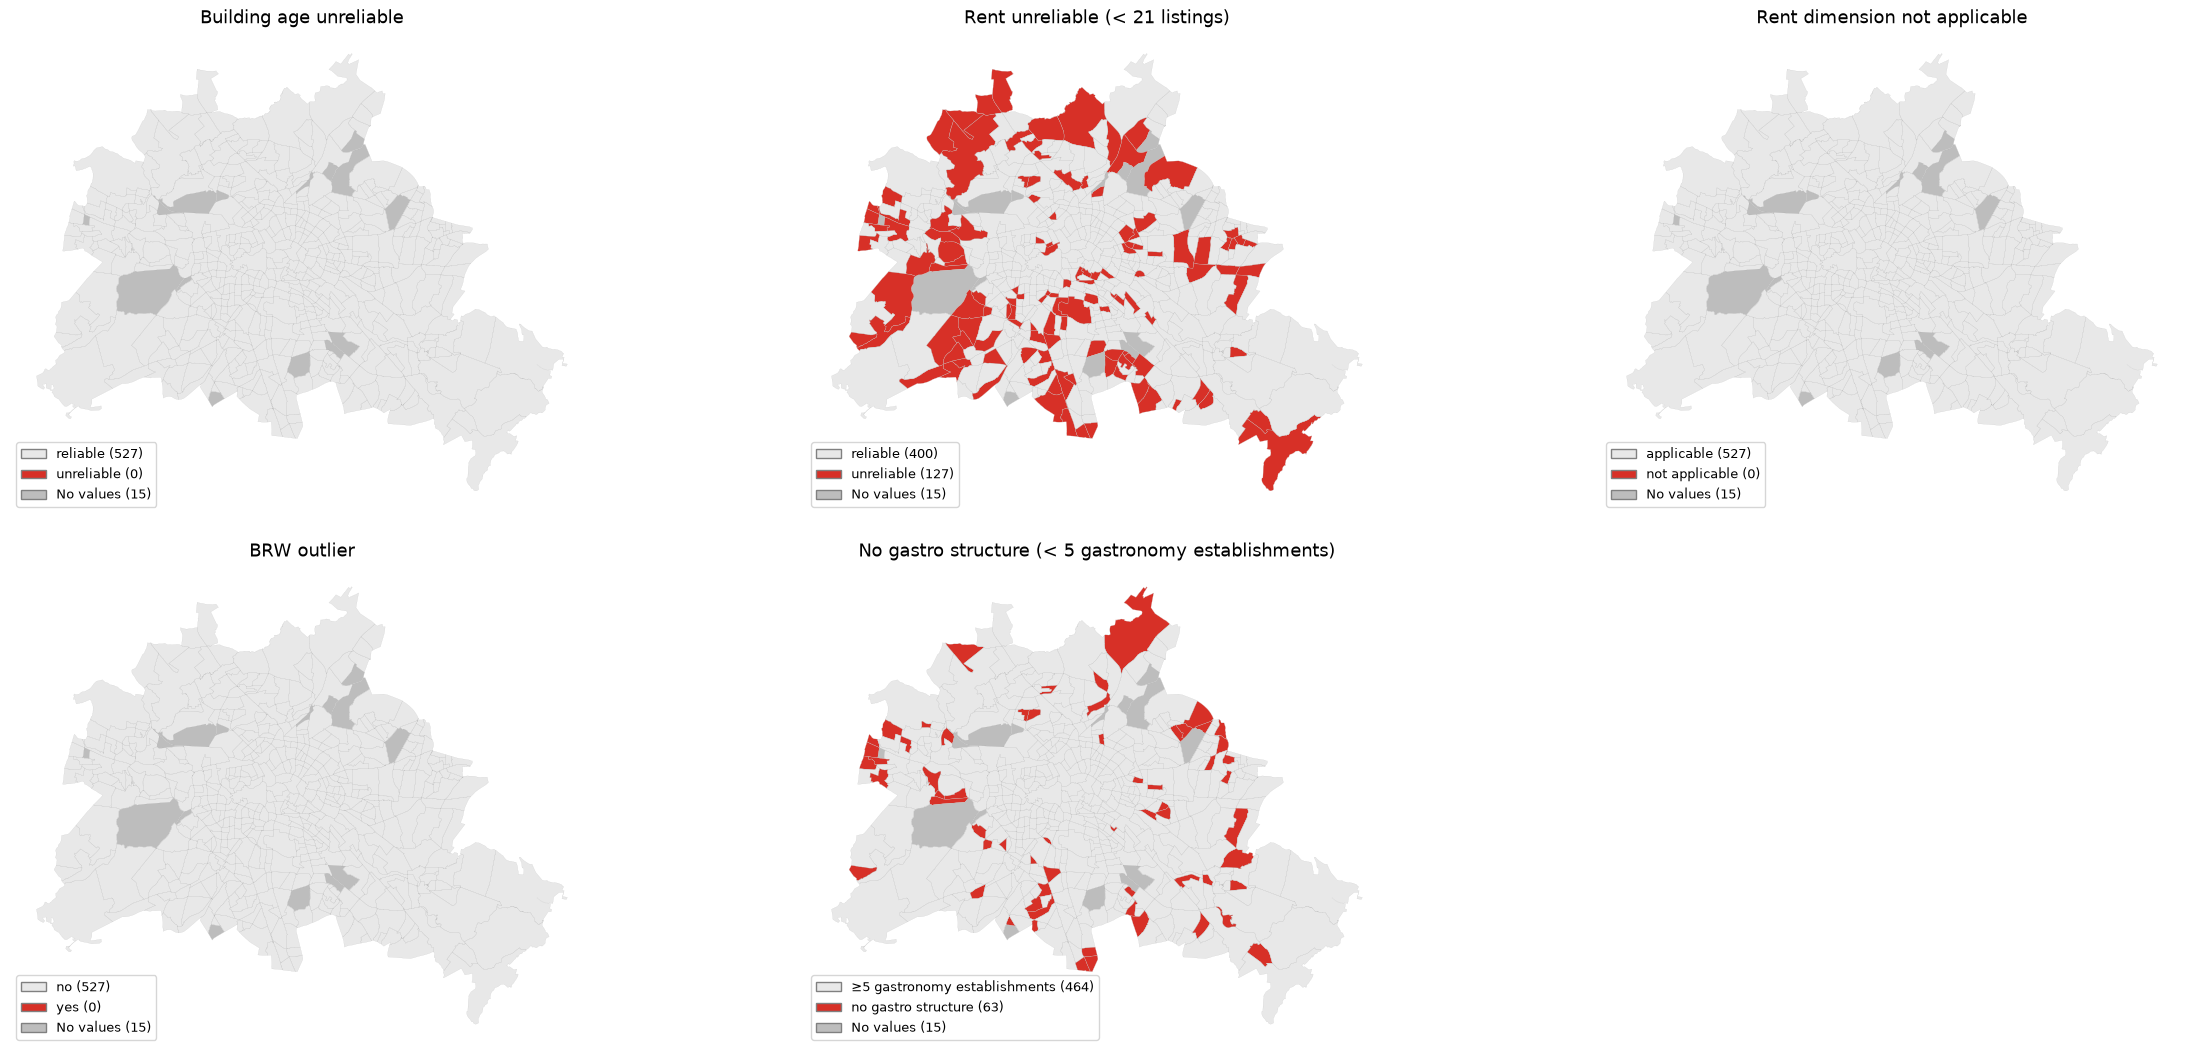

In [429]:
flags = ["re_baualter_unsicher", "re_miete_unsicher",
         "re_miet_dimension_anwendbar", "re_brw_trend_outlier","com_has_gastro_structure"]

df_flags = df_model.assign(plr_id=df["plr_id"].astype(str).str.zfill(8))[["plr_id"] + flags]
gdf = plr.merge(df_flags, on="plr_id", how="left")
print(gdf[flags].notna().any(axis=1).sum(), "von", len(gdf), "gematcht")

flag_styles = {
    "re_baualter_unsicher": {"title": "Building age unreliable",
        "map": {0: ("reliable", "#e8e8e8"), 1: ("unreliable", "#d73027")}},
    "re_miete_unsicher": {"title": "Rent unreliable (< 21 listings)",
        "map": {0: ("reliable", "#e8e8e8"), 1: ("unreliable", "#d73027")}},
    "re_miet_dimension_anwendbar": {"title": "Rent dimension not applicable",
        "map": {1: ("applicable", "#e8e8e8"), 0: ("not applicable", "#d73027")}},
    "re_brw_trend_outlier": {"title": "BRW outlier",
        "map": {0: ("no", "#e8e8e8"), 1: ("yes", "#d73027")}},
    "com_has_gastro_structure": {"title": "No gastro structure (< 5 gastronomy establishments)",
        "map": {1: ("≥5 gastronomy establishments", "#e8e8e8"), 0: ("no gastro structure", "#d73027")}}
}

fig, axes = plt.subplots(3, 3, figsize=(24, 16))

for ax, (col, style) in zip(axes.flat, flag_styles.items()):
    vmap = style["map"]
    colors = gdf[col].map({k: v[1] for k, v in vmap.items()}).fillna("#bdbdbd")
    gdf.plot(ax=ax, color=colors, edgecolor="white", linewidth=0.15)
    gdf.boundary.plot(ax=ax, edgecolor="black", linewidth=0.1, alpha=0.3)

    counts = gdf[col].value_counts(dropna=False)
    handles = [Patch(facecolor=v[1], edgecolor="grey",
                     label=f"{v[0]} ({int(counts.get(k, 0))})")
               for k, v in vmap.items()]
    if gdf[col].isna().any():
        handles.append(Patch(facecolor="#bdbdbd", edgecolor="grey",
                             label=f"No values ({int(gdf[col].isna().sum())})"))
    ax.legend(handles=handles, loc="lower left", fontsize=9, frameon=True)
    ax.set_title(style["title"], fontsize=13)
    ax.axis("off")

# leere Zellen ausblenden (hier die 6.)
for ax in axes.flat[len(flag_styles):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [430]:
#Which PLR still flagged? (check only flags still present in df_model)
for flag in ["re_baualter_unsicher", "re_brw_trend_outlier", "re_miet_dimension_anwendbar", "re_miete_unsicher", "com_has_gastro_structure"]:
    if flag not in df_model.columns:
        print(f"{flag}: already dropped\n")
        continue
    n_flagged = (df_model[flag] == 1).sum()
    print(f"{flag}:")
    print(f"  PLR flagged == 1: {n_flagged}")
    print(f"  Distinct values: {df_model[flag].nunique()}")
    print(df_model[flag].value_counts(dropna=False).to_string())
    print()

re_baualter_unsicher:
  PLR flagged == 1: 0
  Distinct values: 1
re_baualter_unsicher
0.0    527

re_brw_trend_outlier:
  PLR flagged == 1: 0
  Distinct values: 1
re_brw_trend_outlier
0    527

re_miet_dimension_anwendbar:
  PLR flagged == 1: 527
  Distinct values: 1
re_miet_dimension_anwendbar
1    527

re_miete_unsicher:
  PLR flagged == 1: 127
  Distinct values: 2
re_miete_unsicher
0    400
1    127

com_has_gastro_structure:
  PLR flagged == 1: 464
  Distinct values: 2
com_has_gastro_structure
1    464
0     63



In [431]:
#decision: drop them as they are a constant after dropping 8 PLRs
df_model = df_model.drop(columns=[c for c in
    ["re_baualter_unsicher", "re_brw_trend_outlier", "re_miet_dimension_anwendbar"]
    if c in df_model.columns])
print(df_model.shape)

#decision 2: drop the other ones too because they are redundant in the model 
df_model = df_model.drop(columns=[c for c in
    ["com_has_gastro_structure", "re_miete_unsicher", "re_cov_wohnen_2025"]
    if c in df_model.columns])
print(df_model.shape)


(527, 50)
(527, 47)


## 4) Skew

In [432]:
# skew per feature, sorted by magnitude

#define id columns and feature columns
id_cols = ["plr_id", "plr_name", "bez"]

feat_cols = [c for c in df_model.columns if c not in id_cols]

skew = df_model[feat_cols].skew().sort_values(key=abs, ascending=False)

# severity band + whether the feature has negatives (matters for log vs yeo-johnson)
def band(s):
    a = abs(s)
    if a < 0.5: return "≈ symmetric (<0.5)"
    if a < 1:   return "mild (0.5–1)"
    if a < 2:   return "strong (1–2)"
    return "severe (>2)"

overview = pd.DataFrame({
    "skew": skew.round(2),
    "band": skew.map(band),
    "has_negatives": [df_model[c].min() < 0 for c in skew.index],
})

print(overview.to_string())
print("\nSummary:")
print(overview["band"].value_counts()
      .reindex(["severe (>2)", "strong (1–2)", "mild (0.5–1)", "≈ symmetric (<0.5)"]).to_string())
print(f"\nFeatures with negatives: {overview['has_negatives'].sum()} of {len(feat_cols)}")

                                                               skew                band  has_negatives
n_missing                                                     20.31         severe (>2)          False
com_entry_rate_slope                                         -14.96         severe (>2)           True
com_tourism_share_slope                                       14.51         severe (>2)           True
com_tourism_share_level_2026                                  11.43         severe (>2)          False
soc_internal_net_migration_rate_2025                          -7.58         severe (>2)           True
re_dichte_all                                                  3.82         severe (>2)          False
soc_internal_migration_volume_rate_2025                        3.76         severe (>2)          False
soc_internal_net_migration_rate_change_2021_2025              -3.75         severe (>2)           True
re_neubau_share                                                3.56      

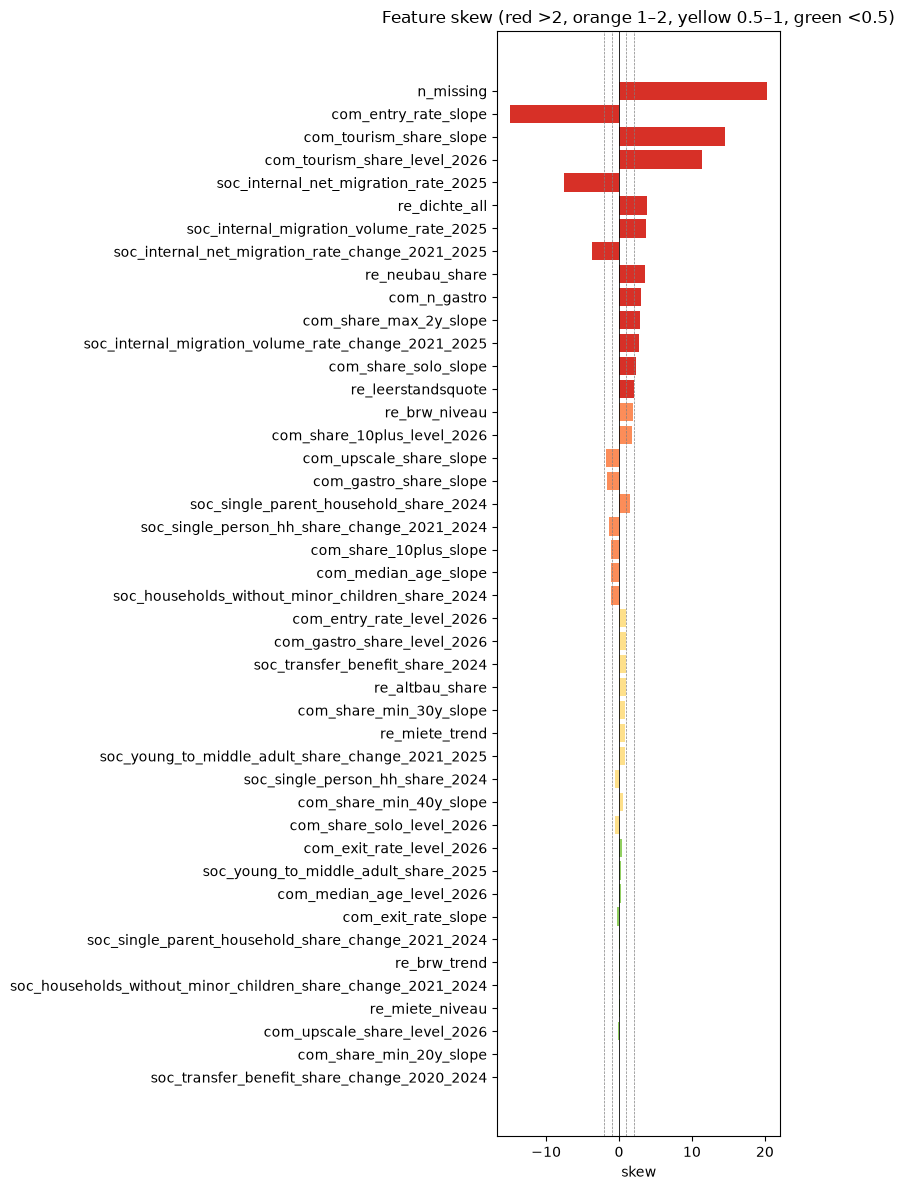

In [433]:
fig, ax = plt.subplots(figsize=(8, 12))
colors = skew.map(lambda s: "#d73027" if abs(s) > 2 else
                            "#fc8d59" if abs(s) > 1 else
                            "#fee08b" if abs(s) > 0.5 else "#91cf60")
ax.barh(skew.index[::-1], skew.values[::-1], color=colors.values[::-1])
ax.axvline(0, color="black", linewidth=0.6)
for x in (-2, -1, 1, 2):
    ax.axvline(x, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel("skew")
ax.set_title("Feature skew (red >2, orange 1–2, yellow 0.5–1, green <0.5)")
plt.tight_layout()
plt.show()

Half of the features (22 of 44) are strongly or severely skewed, and 22 carry negative values. This has to be kept in mind when standardizing the variables later.

## 5) Outliers

Let's look for outliers that could impact the scaling and modeling. The first step is to look at boxplots for each dimension.

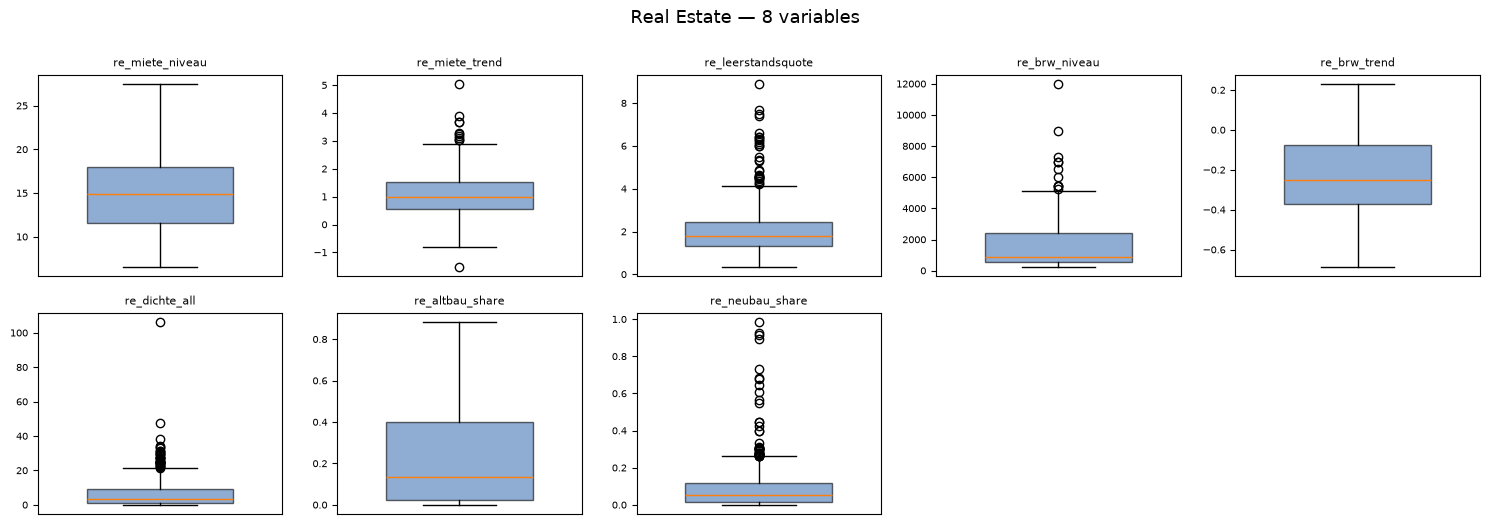

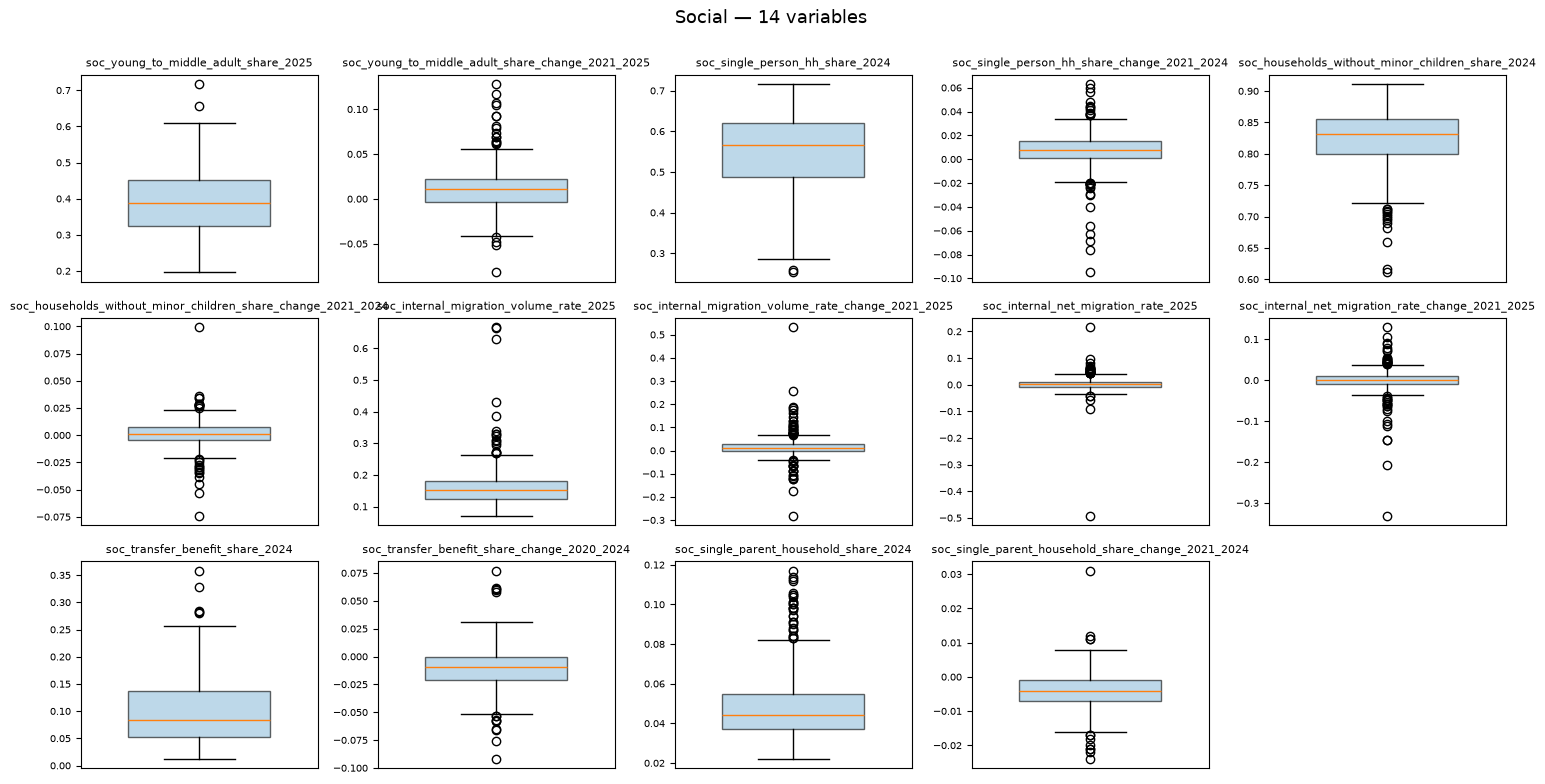

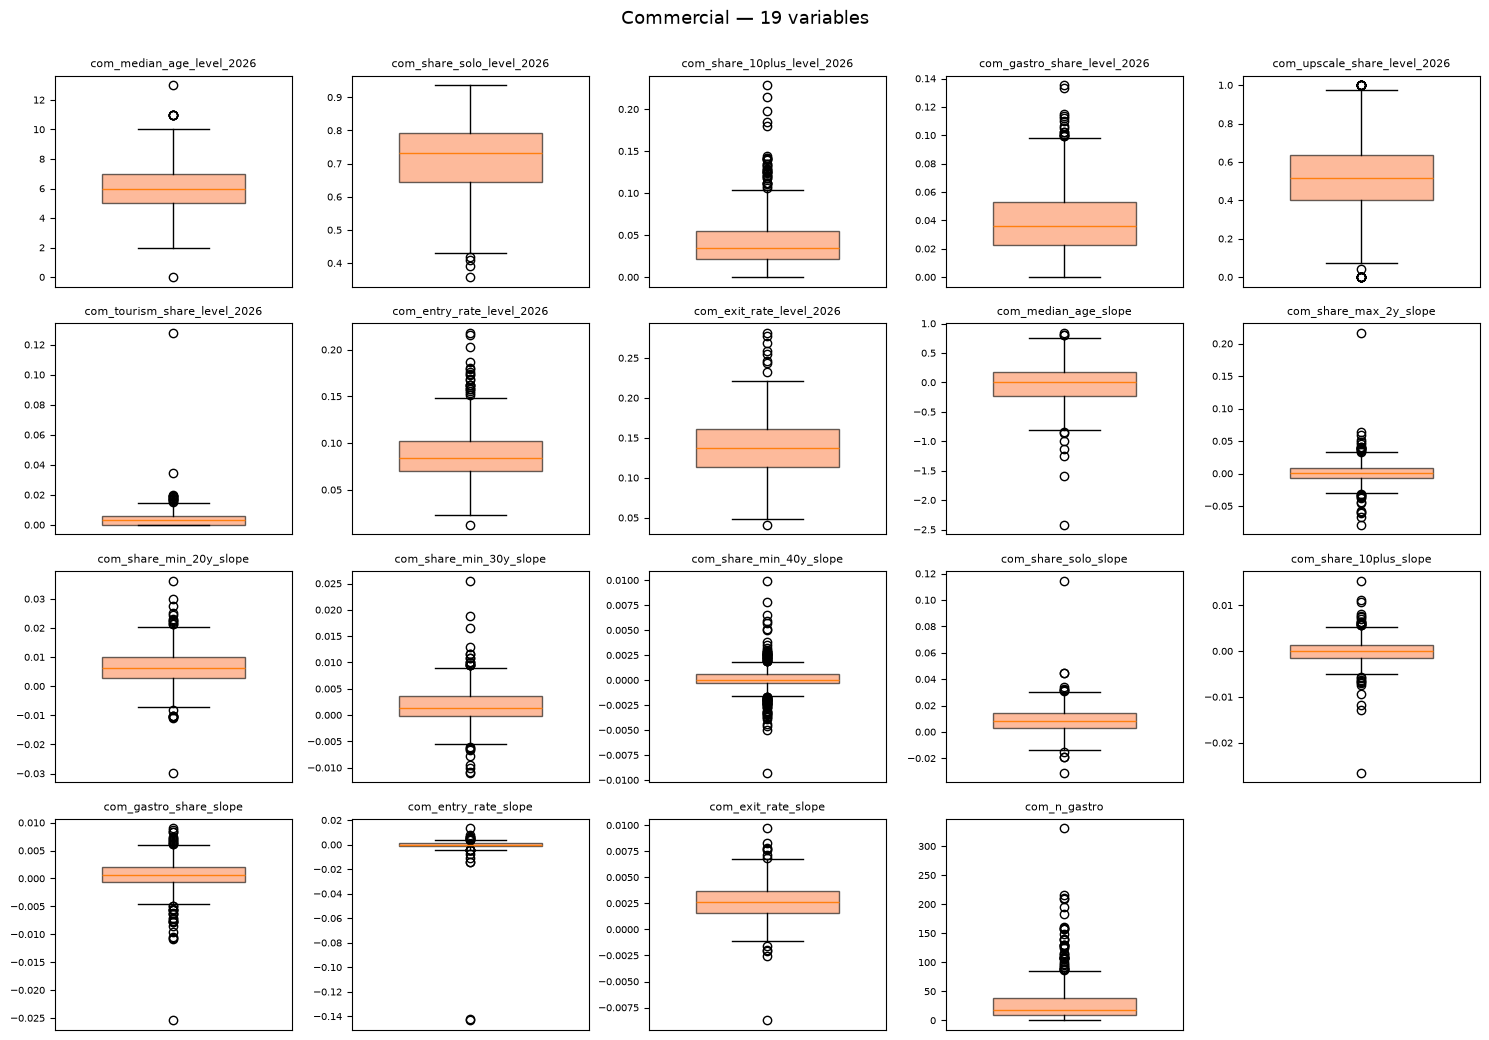

In [452]:
import math

dimensions = {
    "Real Estate": ([c for c in feat_cols if c.startswith("re_")],  "#4575b4"),
    "Social":      ([c for c in feat_cols if c.startswith("soc_")], "#91bfdb"),
    "Commercial":  ([c for c in feat_cols if c.startswith("com_")], "#fc8d59"),
}

for dim_name, (cols, col_color) in dimensions.items():
    n = len(cols)
    ncols = 5
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.6))
    axes = axes.flatten() if n > 1 else [axes]

    for ax, c in zip(axes, cols):
        bp = ax.boxplot(df_model[c].dropna(), widths=0.6, patch_artist=True)
        bp["boxes"][0].set_facecolor(col_color)
        bp["boxes"][0].set_alpha(0.6)
        ax.set_title(c, fontsize=8)
        ax.set_xticks([])
        ax.tick_params(axis="y", labelsize=7)

    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle(f"{dim_name} — {n} variables", fontsize=13, y=1.0)
    plt.tight_layout()

    plt.show()

The real estate variables look unremarkable. re_miete_niveau, re_brw_trend, and re_altbau_share show no outliers; re_brw_niveau, re_dichte_all, and re_neubau_share have long upper tails with several outliers, but the spread is smooth rather than spiky.

In the social dimension, the four internal migration variables stand out — soc_internal_net_migration_rate_2025, soc_internal_migration_volume_rate_2025, and their _change_2021_2025 variants. They show a tight box with extreme values flung far to one or both sides. The remaining social variables look well distributed.

In the commercial dimension, several variables look suspicious:
- com_tourism_share_slope — a near-flat box at zero with a single far outlier and a dense cloud of points.
- com_entry_rate_slope — almost all values at zero with two extreme points pulled far down.
- com_upscale_share_slope and com_gastro_share_slope — a thin box surrounded by outliers on both sides.
- com_share_min_40y_slope — a flat box with an unusually large number of outliers.
- com_tourism_share_level is strongly right-skewed (most PLRs near zero, a few high values), but the spread is smooth.

Let's look at the outliers more closely: 

In [453]:
# helper: counts a column's IQR outliers and their share in %
def iqr_stats(s):
    s = s.dropna()                              # ignore NaN
    q1, q3 = s.quantile([.25, .75])             # 1st and 3rd quartile (= box edges)
    iqr = q3 - q1                               # interquartile range (= box height)
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr         # whisker bounds (Tukey rule, factor 1.5)
    n_out = int(((s < lo) | (s > hi)).sum())    # count of values outside the whiskers
    return n_out, n_out / len(s) * 100          # absolute count + share in percent

# build the table: per variable, skew + outlier metrics
tab = pd.DataFrame([
    {"variable": c,
     "skew": round(df_model[c].skew(), 2),             # skew (asymmetry of the distribution)
     "n_outliers": iqr_stats(df_model[c])[0],          # number of IQR outliers
     "outlier_%": round(iqr_stats(df_model[c])[1], 1)} # share of IQR outliers
    for c in feat_cols
])

tab["abs_skew"] = tab["skew"].abs()             # magnitude of skew (direction doesn't matter)

# "suspicious" rule: strongly skewed OR many outliers
# -> catches both failure modes (long smooth tail AND detached spikes)
tab["flagged"] = (tab["abs_skew"] > 3) | (tab["outlier_%"] > 10) 

# 
# sort: flagged first, then worst skew, then most outliers
tab = tab.sort_values(
    ["flagged","outlier_%","abs_skew"],
    ascending=[False, False, False]   # flagged True on top, then descending
)

print(tab[["variable", "skew", "n_outliers", "outlier_%", "flagged"]].to_string(index=False))

KeyError: 'plr_id_key'

Two of the suspicious variables the your boxplot description are not in the flagged list:

- com_upscale_share_slope — 8.0% outliers, skew −1.77
- com_gastro_share_slope — 6.5% outliers, skew −1.71

These two fall just below the thresholds (outlier share < 10%, |skew| < 3), so the rule does not catch them — but the boxplots clearly do. A reason for this might be the fact that these variables are within-gastro/tourism share-slopes, whose values become unstable when a PLR has only a few gastro businesses. The instability is structural (a small denominator) rather than a matter of raw outlier count, so it does not always surface as a high outlier percentage. For the social dimension, we know that all PLR's except for Nonnendammallee (which has 500) have > 1000 inhabitants, meaning that the outliers are real movement and should not be discarded. 

For the social dimension, we need to examine the outliers per variable individually — identifying which PLRs drive the tails and checking each against the relevant business base (n_gastro for gastro/upscale shares, n_tourism for tourism shares) — to distinguish genuine signal (real structure on a solid base) from small-base artifacts. Both flagged and not-flagged suspicious variables are included in this check, so that the two variables the rule missed are not dropped from the investigation. 

### Outlier Check: Commercial Dimension

In [ ]:
#load tourism share out of the yearly panel
yearly = pd.read_csv("../../data/commercial/IHK_Berlin_Gewerbedaten/analysis_ready_data/yearly_panel_merged.csv",
    dtype={"planungsraum_id": str})

# n_tourism für ein bestimmtes Jahr (z.B. 2025) herausziehen
n_2026 = yearly.loc[yearly["year"] == 2026, ["planungsraum_id", "n_total","n_tourism"]]
print(n_2026.head())

     planungsraum_id      n_total  n_tourism
1626        01100101   738.333333  12.666667
1627        01100102  1555.166667  11.166667
1628        01100103  1397.833333  16.000000
1629        01100104   841.833333   4.000000
1630        01100205  1723.333333  24.000000


In [ ]:
# add tourism and business counts to dataframe
df_model = df_model.merge(
    n_2026.rename(columns={"planungsraum_id": "plr_id"})
             .assign(plr_id=lambda d: d["plr_id"].astype(str).str.zfill(8))
             [["plr_id", "n_tourism", "n_total"]],          # n_total ergänzt
    left_on=df_model["plr_id"].astype(str).str.zfill(8),
    right_on="plr_id", how="left", suffixes=("", "_key")
)
print("gematcht:", df_model[["n_tourism", "n_total"]].notna().all(axis=1).sum(), "von", len(df_model))
print("PLRs mit ~0 Tourismus (<0.5):", (df_model["n_tourism"] < 0.5).sum(), "von", len(df_model))
print("PLRs mit n_tourism < 3:", (df_model["n_tourism"] < 3).sum())

gematcht: 527 von 527
PLRs mit ~0 Tourismus (<0.5): 155 von 527
PLRs mit n_tourism < 3: 337


A large majority of PLRs have less than 3 tourism establishments. This means that the share slope will be very unstable and noisy. Let's look at the base for the other commercial variables.

In [ ]:
suspicious = ["com_tourism_share_slope", "com_share_min_40y_slope",
              "com_entry_rate_slope", "com_tourism_share_level_2026",
              "com_upscale_share_slope", "com_gastro_share_slope"]

# map each variable to the base that actually applies to it
base_for = {
    "com_entry_rate_slope":          "n_total",       # alle Betriebe
    "com_gastro_share_slope":        "n_total",       # Gastro / alle Betriebe
    "com_share_min_40y_slope":       "n_total",
    "com_upscale_share_slope":       "com_n_gastro",  # Upscale / Gastro
    "com_tourism_share_slope":       "n_tourism",
    "com_tourism_share_level_2026":  "n_tourism",
}

def iqr_out(s):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    return s[(s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)]

for c in suspicious:
    base = base_for[c]
    have_base = base in df_model.columns          # n_tour only present if merged in
    ext = iqr_out(df_model[c]).abs().sort_values(ascending=False).head(8).index
    print(f"\n{c}  (base = {base}{'' if have_base else '  — NOT in df_model, merge first'})")
    for i in ext:
        b = f"{df_model[base][i]:.0f}" if have_base else "?"
        print(f"   {df_model[c][i]:+.4g}   {df_model['plr_name'][i]:28s} {base}={b}")


com_tourism_share_slope  (base = n_tourism)
   +0.02796   Perelsplatz                  n_tourism=156
   -0.004516   Heiligensee Nord             n_tourism=1
   -0.003456   Gleisdreieck                 n_tourism=5
   +0.003393   Maulbeerallee                n_tourism=7
   -0.003284   Vogelviertel Süd             n_tourism=4
   -0.00316   Flatowallee                  n_tourism=2
   -0.002873   Londoner Straße              n_tourism=0
   -0.002561   Alt-Gatow                    n_tourism=2

com_share_min_40y_slope  (base = n_total)
   +0.009958   Am Forstacker                n_total=130
   -0.009256   Barbarossaplatz              n_total=985
   +0.00785   Siedlung Kämmereiheide       n_total=71
   +0.006535   Messelpark                   n_total=253
   +0.005936   Kafkastraße                  n_total=273
   +0.005752   Binger Straße                n_total=241
   +0.005116   Thomasiusstraße              n_total=762
   +0.005058   Wriezener Bahnhof            n_total=600

com_entry_rate_sl

Commercial dimension — base-size check

Each suspicious variable was checked against its own denominator. Share-slopes only collapse when the denominator is a thin sub-category. Redundancy was checked for the remaining candidates (min-age slope family, gastro slope vs. level): all correlations ≤ 0.39, so none are redundant.

**Drop:**
- com_upscale_share_slope — base n_gastro; extremes on 1–4 businesses. Noise.
- com_tourism_share_slope — base n_tourism; extremes on 0–7, and 64% of PLRs have < 3 tourism businesses.

**Keep:**
- com_tourism_share_level — real hubs on solid bases (Perelsplatz 156); a 0 is a genuine value.
- com_gastro_share_slope — base n_total (large bases); not redundant with its level (r = 0.37). No reason to drop.
- com_entry_rate_slope — base n_total; all extremes on large bases (Karow 258/404, Ringstraße 2537), so they are real movements, not artifacts.
- com_share_min_40y_slope — base n_total (large bases); not redundant with its 20y/30y siblings (r ≤ 0.39). A flat box with a high outlier share makes it weakly informative, but its outliers are real, so there is no small-base or redundancy reason to drop.

**Note on outliers:** the remaining extreme values (e.g. Karow on com_entry_rate_slope) sit on large bases and are real, not artifacts. Yeo-Johnson is expected to compress them. These variables are kept as-is; capping is a last resort only if a point remains disproportionate after transformation (e.g. if a single extreme still distorts the fitted λ) — not an automatic response to a spiky boxplot.

Rule: divided by a thin sub-category → collapses → drop; divided by all businesses → broad base → keep. Base size decides keep-vs-drop; the transform handles magnitude; capping only if a real-but-extreme point still distorts after transformation.

In [ ]:
#Drop Variables: 
df_model = df_model.drop(columns=["com_upscale_share_slope", "com_tourism_share_slope", "n_total", "n_tourism"])

In [ ]:
df_model.shape

(527, 46)

In [ ]:
# the four suspicious social migration variables
migr = [c for c in df_model.columns if c.startswith("soc_") and "migration" in c]

# return a column's IQR outliers (Tukey rule)
def iqr_out(s):
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    return s[(s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)]

# per variable: the most extreme outlier PLRs by name
for c in migr:
    ext = iqr_out(df_model[c])
    ext_idx = ext.abs().sort_values(ascending=False).head(8).index
    print(f"\n{c}  — {len(ext)} outliers")
    for i in ext_idx:
        print(f"   {df_model[c][i]:+.4g}   {df_model['plr_name'][i]} ({df_model['bez'][i]})")


soc_internal_migration_volume_rate_2025  — 17 outliers
   +0.666   Volkspark Prenzlauer Berg (03 - Pankow)
   +0.664   Wittenau Süd (12 - Reinickendorf)
   +0.63   Paradestraße (07 - Tempelhof-Schöneberg)
   +0.429   Bornitzstraße (11 - Lichtenberg)
   +0.387   Freiheit (05 - Spandau)
   +0.338   Herzbergstraße (11 - Lichtenberg)
   +0.33   Stralauer Kiez (02 - Friedrichshain-Kreuzberg)
   +0.329   Dorf Falkenberg (11 - Lichtenberg)

soc_internal_migration_volume_rate_change_2021_2025  — 46 outliers
   +0.531   Paradestraße (07 - Tempelhof-Schöneberg)
   -0.281   Haveleck (05 - Spandau)
   +0.257   Volkspark Prenzlauer Berg (03 - Pankow)
   +0.188   Freiheit (05 - Spandau)
   +0.182   Angerburger Allee (04 - Charlottenburg-Wilmersdorf)
   +0.176   Marzahner Chaussee (10 - Marzahn-Hellersdorf)
   -0.173   Herzbergstraße (11 - Lichtenberg)
   +0.162   Askanischer Platz (02 - Friedrichshain-Kreuzberg)

soc_internal_net_migration_rate_2025  — 31 outliers
   -0.492   Wittenau Süd (12 - Rei

In [ ]:
# count how many of the four migration variables each PLR is an outlier on
flags = pd.DataFrame(index=df_model.index)
for c in migr:
    flags[c] = df_model.index.isin(iqr_out(df_model[c]).index)

df_model_rep = df_model.assign(n_migr_outlier=flags.sum(axis=1))
repeat = (df_model_rep.loc[df_model_rep["n_migr_outlier"] > 0,
                     ["plr_id", "plr_name", "bez", "n_migr_outlier"]]
                .sort_values("n_migr_outlier", ascending=False))
print(repeat.to_string(index=False))

  plr_id                  plr_name                             bez  n_migr_outlier
10100311        Marzahner Chaussee        10 - Marzahn-Hellersdorf               4
12500930              Wittenau Süd              12 - Reinickendorf               4
05100317                  Freiheit                    05 - Spandau               4
02100101         Askanischer Platz   02 - Friedrichshain-Kreuzberg               4
09100409 Landschaftspark Adlershof           09 - Treptow-Köpenick               4
03300516               Heinersdorf                     03 - Pankow               3
04200204         Angerburger Allee 04 - Charlottenburg-Wilmersdorf               3
09401329   Kietzer Feld/Nachtheide           09 - Treptow-Köpenick               3
05100103             Mertensstraße                    05 - Spandau               3
07400721              Paradestraße       07 - Tempelhof-Schöneberg               3
11100102           Dorf Falkenberg                11 - Lichtenberg               3
0320

## 6) Correlations 

The last and final step is to examine correlations between variables one last time. We already know that some of the data is skewed and not always distributed which means that we will use the Spearman Correlation. 

In [443]:
df_model = df_model.drop(columns="n_missing")

In [444]:
id_cols = ["plr_id", "plr_name", "bez"]
feat_cols = [c for c in df_model.columns if c not in id_cols]

def pair_series(method):
    corr = df_model[feat_cols].corr(method=method)
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    return (upper.stack()
                 .rename(method)
                 .rename_axis(["var1", "var2"]))

# both methods, aligned on the same var1/var2 pairs
both = pd.concat([pair_series("pearson"), pair_series("spearman")], axis=1).reset_index()

# keep pairs where EITHER method exceeds 0.6
mask = (both["pearson"].abs() > 0.6) | (both["spearman"].abs() > 0.6)
high = (both[mask]
        .assign(max_abs=lambda d: d[["pearson", "spearman"]].abs().max(axis=1))
        .sort_values("max_abs", ascending=False)
        .drop(columns="max_abs")
        .reset_index(drop=True))

print(high.round(2).to_string(index=False))

                                            var1                                             var2  pearson  spearman
                 soc_single_person_hh_share_2024 soc_households_without_minor_children_share_2024     0.79      0.81
                       com_share_solo_level_2026                      com_share_10plus_level_2026    -0.75     -0.74
                     com_gastro_share_level_2026                                     com_n_gastro     0.61      0.74
                                   re_brw_niveau                                    re_dichte_all     0.63      0.73
                                   re_dichte_all                                  re_altbau_share     0.57      0.73
                                   re_brw_niveau                                  re_altbau_share     0.63      0.73
                        com_exit_rate_level_2026                              com_exit_rate_slope     0.68      0.73
                                 re_miete_niveau                

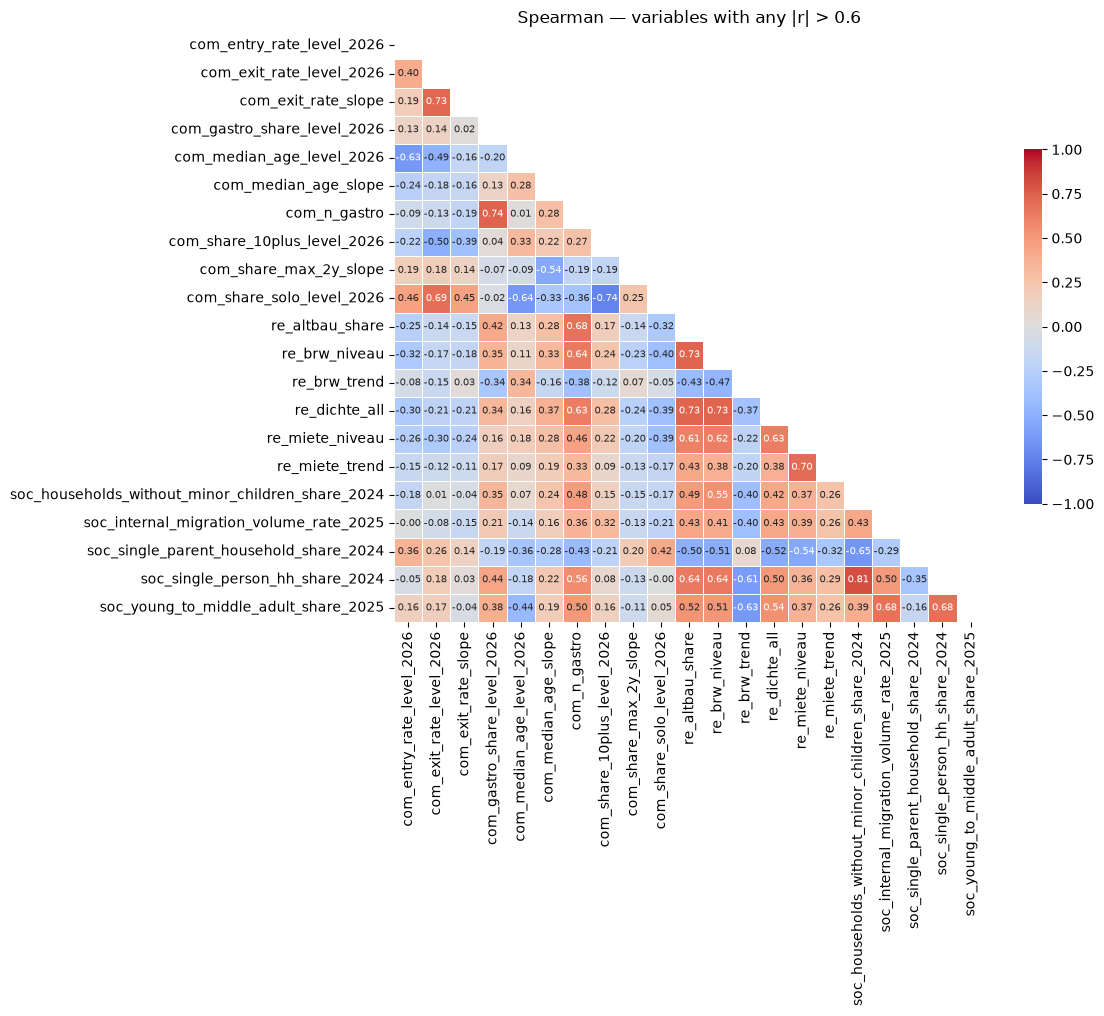

In [445]:
from pathlib import Path
id_cols = ["plr_id", "plr_name", "bez"]
feat_cols = [c for c in df_model.columns if c not in id_cols]

def pair_series(method):
    c = df_model[feat_cols].corr(method=method)
    u = c.where(np.triu(np.ones(c.shape), k=1).astype(bool))
    return u.stack().rename(method).rename_axis(["var1", "var2"])

# variables involved in any |r| > 0.6 pair (Spearman + Pearson, so nothing borderline is missed)
import pandas as pd
both = pd.concat([pair_series("pearson"), pair_series("spearman")], axis=1).reset_index()
high = both[(both["pearson"].abs() > 0.6) | (both["spearman"].abs() > 0.6)]
involved = sorted(set(high["var1"]) | set(high["var2"]))

# Spearman heatmap, restricted to those variables
sub = df_model[involved].corr(method="spearman")
mask = np.triu(np.ones(sub.shape)).astype(bool)

plt.figure(figsize=(12, 10))
sns.heatmap(sub, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.6})
plt.title("Spearman — variables with any |r| > 0.6")
plt.tight_layout()

# save first, then show (avoids the blank-file issue)
Path("../../plots/EDA").mkdir(parents=True, exist_ok=True)   # adjust path if needed
plt.savefig("../../plots/EDA/spearman_corr_above06.png", dpi=150, bbox_inches="tight")
plt.show()

The variables `soc_single_person_hh_share_2024` and `soc_households_without_minor_children_share_2024` are strongly correlated and sit right at the 0.8 threshold (Pearson 0.79, Spearman 0.81). This is expected, since single-person households are by definition a subset of households without minor children. Keeping both would overweight the shared "households without children" dimension in the distance calculation, though they are not identical.

Three options:

1. Drop the broader variable (households_without_minor_children) → keeps a more specific signal (single households), at the cost of losing childless couples and shared flats.
2. Drop the single households → keeps the broader "no children" household structure, at the cost of the specific singularization signal.
3. Given the correlation only just reaches the threshold, keeping both is also defensible. This is a borderline case in the dataset and should be decided deliberately rather than by the rule alone.

## 7) Final Overview 

In [446]:
df_model.columns

Index(['plr_id', 'plr_name', 'bez', 're_miete_niveau', 're_miete_trend',
       're_leerstandsquote', 're_brw_niveau', 're_brw_trend', 're_dichte_all',
       'soc_young_to_middle_adult_share_2025',
       'soc_young_to_middle_adult_share_change_2021_2025',
       'soc_single_person_hh_share_2024',
       'soc_single_person_hh_share_change_2021_2024',
       'soc_households_without_minor_children_share_2024',
       'soc_households_without_minor_children_share_change_2021_2024',
       'soc_internal_migration_volume_rate_2025',
       'soc_internal_migration_volume_rate_change_2021_2025',
       'soc_internal_net_migration_rate_2025',
       'soc_internal_net_migration_rate_change_2021_2025',
       'soc_transfer_benefit_share_2024',
       'soc_transfer_benefit_share_change_2020_2024',
       'soc_single_parent_household_share_2024',
       'soc_single_parent_household_share_change_2021_2024',
       'com_median_age_level_2026', 'com_share_solo_level_2026',
       'com_share_10plus_le

In [447]:
#drop plr_id_key
df_model = df_model.drop(columns="plr_id_key")

In [448]:
#final shape
df_model.shape

(527, 44)

In [449]:
#inspect missing columns per PLR
# readable: each PLR with exactly its missing columns
mask = df_model.isna().any(axis=1)
for _, r in df_model.loc[mask].iterrows():
    miss = list(r.index[r.isna()])
    print(f"{r['plr_id']} — {r['plr_name']}: {', '.join(miss)}")

07200412 — Schöneberger Linse: re_brw_niveau, re_brw_trend
11300723 — Bornitzstraße: re_miete_trend


The PLR's Schöneberger Linse & Bornitzstraße are the only ones with missing values. These three values will be inputed at the modeling stage.

In [450]:
#save the new dataset 
out_path = "../../data/final_datasets/dataset_0.csv"
df_model.to_csv(out_path, index=False)
print(f"Saved {df_model.shape[0]} PLR × {df_model.shape[1]} cols → {out_path}")

Saved 527 PLR × 44 cols → ../../data/final_datasets/dataset_0.csv


In [451]:
#sanity check 
check = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})
print(check.shape)                                  # (527, 44)
print(check["plr_id"].iloc[0], "len:", len(check["plr_id"].iloc[0]))   # 8-stellig

(527, 44)
01100101 len: 8


In [408]:
#look at variables per dimension
id_cols = ["plr_id", "plr_name", "bez"]
feat_cols = [c for c in df_model.columns if c not in id_cols]

# Variablen per dimension über
re_vars  = [c for c in feat_cols if c.startswith("re_")]
soc_vars = [c for c in feat_cols if c.startswith("soc_")]
com_vars = [c for c in feat_cols if c.startswith("com_")]

print(f"real estate : {len(re_vars)}")
print(f"social      : {len(soc_vars)}")
print(f"commercial  : {len(com_vars)}")
print("_____________"*2)
print(f"total       : {len(feat_cols)}")

real estate : 8
social      : 14
commercial  : 19
__________________________
total       : 41


This concludes the final dataset. Two caveats for further processing:
- Unequal number of variables per dimension (real estate 8, social 14, commercial 19). The dimensions must be balanced during modeling so that the commercial dimension is not weighted more heavily simply because it has more variables. 
- Missing values in 2 PLRs — Bornitzstraße (re_miete_trend) and Schöneberger Linse (re_brw_niveau, re_brw_trend) — to be KNN-imputed at the modeling stage, after scaling considerations, since both are genuine residential PLRs with isolated real-estate gaps rather than structural holes.